In [4]:
import pandas as pd
from scipy.stats import chi2_contingency
df=pd.read_csv('archive/diamonds.csv')
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [ ]:
table=pd.crosstab(df['cut'],df['color'])
print(table)

color         D     E     F     G     H     I    J
cut                                               
Fair        163   224   312   314   303   175  119
Good        662   933   909   871   702   522  307
Ideal      2834  3903  3826  4884  3115  2093  896
Premium    1603  2337  2331  2924  2360  1428  808
Very Good  1513  2400  2164  2299  1824  1204  678


In [5]:
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [6]:
df['cut'].value_counts()

cut
Ideal        21551
Premium      13791
Very Good    12082
Good          4906
Fair          1610
Name: count, dtype: int64

In [7]:
df['color'].value_counts()

color
G    11292
E     9797
F     9542
H     8304
D     6775
I     5422
J     2808
Name: count, dtype: int64

In [ ]:
df.isnull().sum()

carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64

In [8]:
table = pd.crosstab(df['carat'], df['cut'])
print(table)

chi2, p, dof, expected = chi2_contingency(table)
alpha = 0.05
print(f'Chi2: {chi2:.2f}, p-value: {p:.4f}, Degrees of freedom: {dof}')


cut    Fair  Good  Ideal  Premium  Very Good
carat                                       
0.20      0     0      3        8          1
0.21      0     0      0        8          1
0.22      1     0      0        4          0
0.23      1    31     44       20        197
0.24      0    14     69       17        154
...     ...   ...    ...      ...        ...
4.00      0     0      0        0          1
4.01      0     0      0        2          0
4.13      1     0      0        0          0
4.50      1     0      0        0          0
5.01      1     0      0        0          0

[273 rows x 5 columns]
Chi2: 9572.61, p-value: 0.0000, Degrees of freedom: 1088


In [9]:
if p < alpha:
    print('Reject null: carat associated with cut.')
else:
    print('No significant association.')

Reject null: carat associated with cut.


In [10]:
table = pd.crosstab(df['carat'], df['clarity'])
print(table)

chi2, p, dof, expected = chi2_contingency(table)
#print(f'p-value: {p:.4f}')
print(f'Chi2: {chi2:.2f}, p-value: {p:.4f}, Degrees of freedom: {dof}')
if p < alpha:
    print('Significant: carat linked to clarity risk.')


clarity  I1  IF  SI1  SI2  VS1  VS2  VVS1  VVS2
carat                                          
0.20      0   0    0    1    0   11     0     0
0.21      0   0    1    1    0    7     0     0
0.22      0   0    2    0    0    3     0     0
0.23      0   7    3    2   37   33    77   134
0.24      0  16    6    0   37   29    74    92
...      ..  ..  ...  ...  ...  ...   ...   ...
4.00      1   0    0    0    0    0     0     0
4.01      2   0    0    0    0    0     0     0
4.13      1   0    0    0    0    0     0     0
4.50      1   0    0    0    0    0     0     0
5.01      1   0    0    0    0    0     0     0

[273 rows x 8 columns]
Chi2: 17062.98, p-value: 0.0000, Degrees of freedom: 1904
Significant: carat linked to clarity risk.


In [11]:
table = pd.crosstab(df['cut'], df['color'])
chi2, p, dof, expected = chi2_contingency(table)
print(f'Chi2: {chi2:.2f}, p-value: {p:.4f}, Degrees of freedom: {dof}')
print(f'p-value for cut vs color: {p:.4f}')


Chi2: 310.32, p-value: 0.0000, Degrees of freedom: 24
p-value for cut vs color: 0.0000


<Axes: ylabel='carat'>

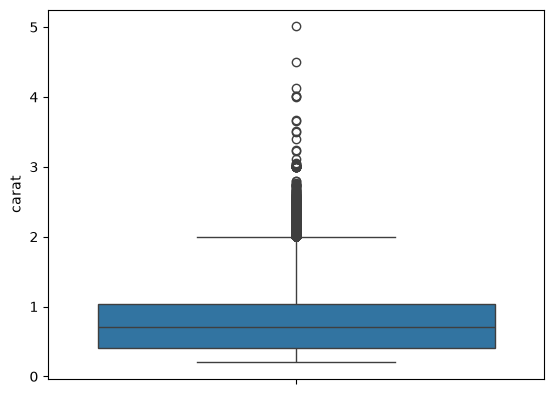

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.boxplot(df['carat'])

In [ ]:
df['carat'].describe()

count    53940.000000
mean         0.797940
std          0.474011
min          0.200000
25%          0.400000
50%          0.700000
75%          1.040000
max          5.010000
Name: carat, dtype: float64

In [13]:
Q1 = df['carat'].quantile(0.25)
Q3 = df['carat'].quantile(0.75)
IQR = Q3 - Q1
print(IQR)

0.64


In [14]:
upper_bound = Q3 + 1.5*IQR
lower_bound = Q1 - 1.5*IQR
df_clean = df[(df['carat'] >= upper_bound) &
              (df['carat'] <= lower_bound)]

In [15]:
# Try Z-score first (works well for right-skewed!)
from scipy import stats
import numpy as np
z_scores = np.abs(stats.zscore(df['carat']))
df_clean = df[z_scores < 2]  # Change threshold as needed

# Check result
print(df_clean.describe())  # Should show improvement!

              carat         depth         table         price             x  \
count  51523.000000  51523.000000  51523.000000  51523.000000  51523.000000   
mean       0.736837     61.746257     57.418993   3432.489548      5.615869   
std        0.386354      1.410222      2.220112   3269.123966      1.007469   
min        0.200000     43.000000     43.000000    326.000000      0.000000   
25%        0.390000     61.100000     56.000000    921.000000      4.680000   
50%        0.700000     61.800000     57.000000   2247.000000      5.640000   
75%        1.010000     62.500000     59.000000   4855.000000      6.460000   
max        1.740000     79.000000     79.000000  18806.000000      8.020000   

                  y             z  
count  51523.000000  51523.000000  
mean       5.619489      3.468056  
std        1.007366      0.636312  
min        0.000000      0.000000  
25%        4.700000      2.890000  
50%        5.640000      3.480000  
75%        6.460000      4.000000  


In [16]:
Q1 = df_clean['carat'].quantile(0.25)
Q3 = df_clean['carat'].quantile(0.75)
IQR = Q3 - Q1
print(IQR)

0.62


In [17]:
df['carat'].describe()

count    53940.000000
mean         0.797940
std          0.474011
min          0.200000
25%          0.400000
50%          0.700000
75%          1.040000
max          5.010000
Name: carat, dtype: float64

In [18]:
df.duplicated().sum()

np.int64(146)

In [19]:
df.dtypes

carat      float64
cut            str
color          str
clarity        str
depth      float64
table      float64
price        int64
x          float64
y          float64
z          float64
dtype: object

In [20]:
df.columns

Index(['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'price', 'x', 'y',
       'z'],
      dtype='str')

In [21]:
x=df.drop('carat',axis=1)
y=df['carat']
x

,cut,color,clarity,depth,table,price,x,y,z
0,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...
53935,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53936,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53937,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53938,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74


In [22]:
x = df.drop(columns=['price','cut','color','clarity'])
y = df['price']

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=100)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)


In [23]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)



In [24]:
from sklearn.metrics import r2_score,mean_absolute_error
print(r2_score(y_test,y_pred))
print(mean_absolute_error(y_test,y_pred))


0.8563544828873428
876.563361394685


In [25]:
from sklearn.ensemble import RandomForestRegressor
rfr=RandomForestRegressor()
rfr.fit(x_train,y_train)
y_pred=rfr.predict(x_test)
from sklearn.metrics import r2_score,mean_absolute_error
print(r2_score(y_test,y_pred))
print(mean_absolute_error(y_test,y_pred))




0.8774085823675927
769.7229010667241


In [28]:
from sklearn.tree import DecisionTreeRegressor
dtr=DecisionTreeRegressor()
dtr.fit(x_train,y_train)
y_pred=dtr.predict(x_test)
from sklearn.metrics import r2_score,mean_absolute_error
print(r2_score(y_test,y_pred))
print(mean_absolute_error(y_test,y_pred))


0.7735722156092459
1016.7782858378797


In [ ]:
from sklearn.svm import SVR
svr=SVR()
svr.fit(x_train,y_train)
y_pred=svr.predict(x_test)
from sklearn.metrics import r2_score,mean_absolute_error
print(r2_score(y_test,y_pred))
print(mean_absolute_error(y_test,y_pred))
